/var/folders/tq/jkwj8f8n5pq9f2q4g1mjl4r40000gn/T/ipykernel_18207/2987196536.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='H')
22:19:43 - cmdstanpy - INFO - Chain [1] start processing
22:20:02 - cmdstanpy - INFO - Chain [1] done processing


Test RMSE: 941,213.19
Test MAE: 825,025.88
Test MSE: 885,882,270,397.84
Test R2: 0.4514
Test MAPE: 360,174,013,559,487.38%

Sample of 2025 forecast:
                    ds          yhat    yhat_lower    yhat_upper
0  2025-01-01 00:00:00  3.600582e+06  3.109474e+06  4.085578e+06
1  2025-01-01 01:00:00  3.600432e+06  3.115708e+06  4.043874e+06
2  2025-01-01 02:00:00  3.641369e+06  3.165676e+06  4.077266e+06
3  2025-01-01 03:00:00  3.644974e+06  3.201944e+06  4.076365e+06
4  2025-01-01 04:00:00  3.677943e+06  3.235086e+06  4.153269e+06
5  2025-01-01 05:00:00  3.620825e+06  3.147657e+06  4.086892e+06
6  2025-01-01 06:00:00  3.638319e+06  3.171943e+06  4.107307e+06
7  2025-01-01 07:00:00  3.602938e+06  3.110541e+06  4.037647e+06
8  2025-01-01 08:00:00  3.613009e+06  3.160923e+06  4.054984e+06
9  2025-01-01 09:00:00  3.718977e+06  3.278545e+06  4.178498e+06
10 2025-01-01 10:00:00  3.816208e+06  3.335015e+06  4.280611e+06
11 2025-01-01 11:00:00  3.850347e+06  3.433582e+06  4.314792e+06
12 202

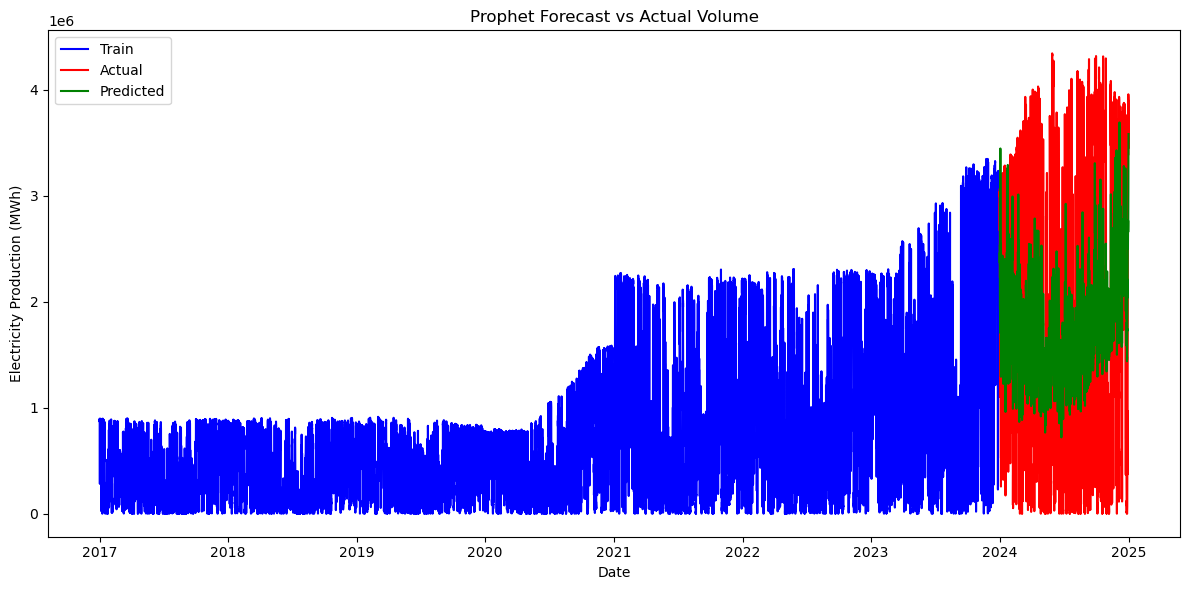

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. LOAD DATA
df = pd.read_csv("final_offshore_data_2017_2025.csv")

# 2. FIX MIDNIGHT HOUR ISSUE
# The column 'correct_days' is assumed to have a format like "YYYY-MM-DD-HH"
df[['date', 'hour_str']] = df['correct_days'].str.rsplit('-', n=1, expand=True)
df['hour'] = df['hour_str'].astype(int) - 1  # Convert "24" -> 23, "01" -> 0, etc.

# 3. CREATE PROPHET-COMPATIBLE COLUMNS
df['ds'] = pd.to_datetime(df['date']) + pd.to_timedelta(df['hour'], unit='H')
df['y'] = df['volume']  # Target variable for Prophet

# 4. ADD ADDITIONAL REGRESSOR (example: wind_speed)
df['wind_speed'] = df['wind_speed_h_avg']

# 5. SPLIT DATA: TRAIN (2017–2023), TEST (2024), FUTURE (2025)
train_df = df[df['ds'] < '2024-01-01'] 
test_df = df[(df['ds'] >= '2024-01-01') & (df['ds'] < '2025-01-01')]
future_df = df[df['ds'] >= '2025-01-01']

# 6. TRAIN PROPHET MODEL
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True
)
model.add_regressor('wind_speed')
model.fit(train_df[['ds','y','wind_speed']])

# 7. FORECAST ON THE TEST PERIOD (2024) AND EVALUATE
forecast_test = model.predict(test_df[['ds','wind_speed']])
test_merged = test_df.merge(
    forecast_test[['ds','yhat','yhat_lower','yhat_upper']], on='ds', how='left'
)

# Error metrics
y_true = test_merged['y']
y_pred = test_merged['yhat']

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

mape = mean_absolute_percentage_error(y_true, y_pred)

print(f"Test RMSE: {rmse:,.2f}")
print(f"Test MAE: {mae:,.2f}")
print(f"Test MSE: {mse:,.2f}")
print(f"Test R2: {r2:,.4f}")
print(f"Test MAPE: {mape:,.2f}%")

# 8. FORECAST FOR 2025
forecast_2025 = model.predict(future_df[['ds','wind_speed']])
print("\nSample of 2025 forecast:")
print(forecast_2025[['ds','yhat','yhat_lower','yhat_upper']].head(24))

# --------- PLOT: TRAIN (blue) vs TEST ACTUAL (red) vs TEST PREDICTED (green) ---------
plt.figure(figsize=(12, 6))

# Plot TRAIN: ds vs. y
plt.plot(train_df['ds'], train_df['y'], color='blue', label='Train')

# Plot TEST Actual: ds vs. y
plt.plot(test_merged['ds'], test_merged['y'], color='red', label='Actual')

# Plot TEST Forecast: ds vs. yhat
plt.plot(test_merged['ds'], test_merged['yhat'], color='green', label='Predicted')

# Customize the chart
plt.title("Prophet Forecast vs Actual Volume")
plt.xlabel("Date")
plt.ylabel("Electricity Production (MWh)")
plt.legend()
plt.tight_layout()
plt.show()
